# Predicción de Fuga de Clientes (Churn) en Telecomunicaciones

Este notebook aborda el problema de la retención de clientes en una empresa de telecomunicaciones. El objetivo es utilizar el dataset "Telco Customer Churn" para entrenar modelos de Machine Learning capaces de identificar con anticipación qué usuarios tienen una alta probabilidad de cancelar su servicio.

A lo largo de este documento, realizaremos la limpieza de datos, ingeniería de características y entrenaremos tres modelos de clasificación (Regresión Logística, SVM y un Árbol de Decisión). Finalmente, evaluaremos su rendimiento priorizando la métrica de Recall (Exhaustividad) para recomendar la mejor opción que ayude al equipo de retención a actuar a tiempo.

Autores: David Ramírez, Octavio Chávez y Felipe Huincaman.

#### Requisitos de Software
Para la correcta ejecución del código en este notebook, se requiere un entorno de Python con las siguientes librerías instaladas:  
- Manejo y análisis de datos: pandas, numpy y scipy
- Visualización: matplotlib y seaborn
- Preprocesamiento y Machine Learning: scikit-learn

#### Importación de librerías necesarias

In [1]:
%pip install feature-engine

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys
sys.path.insert(0, os.path.abspath("../"))
import src.visualizaciones as visualizaciones
from src.feature_engineering import TelcoFeatureEngineer
from src.visualizaciones import plot_matriz_confusion, plot_curva_roc

from IPython.display import display

# omite advertencias
import warnings
warnings.filterwarnings("ignore")

import sklearn
sklearn.set_config(transform_output="pandas")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder
from feature_engine.outliers import Winsorizer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

import hashlib

import scipy.stats as ss

# 1. Análisis Exploratorio de Datos

#### Carga de Data

In [3]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset_crudo.csv")

#### Información inicial de Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.shape

(7043, 21)

* Este conjunto de datos consiste en 7043 registros y 21 características
* El dataset tiene muchas características como data de texto y probablemente sean variables categóricas
* **TotalCharges** contiene valores numéricos pero está almacenada como strings. Vamos a convertir esta variable a tipo numérica (float)
* La variable **SeniorCitizen** indica si el cliente es adulto mayor (0 = "no", 1 = "sí"). Al ser una variable categórica, la convertiremos de tipo numérico a object

### Manipulación de Datos

In [7]:
# convertir columnas de tipo string a object
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')
print(f"Total de columnas convertidas a object: {len(df.select_dtypes(include=['object']).columns)}")

Total de columnas convertidas a object: 18


In [8]:
# convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges convertido a numérico.")

TotalCharges convertido a numérico.


In [9]:
# convertir SeniorCitizen a object para que sea categórico
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: 'No', 1: 'Sí'}).astype(object)
print("SeniorCitizen convertido a object.")

SeniorCitizen convertido a object.


In [10]:
# información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  Paymen

* La variable objetivo que guiará nuestra exploración es el **Churn**.

#### Implementación de Anonimización

* De acuerdo con la legislación sobre protección de la vida privada, almacenar de forma directa el ID del cliente (CustomerID) junto con su comportamiento financiero expone a la empresa a severas multas.

In [11]:
def anonimizar(texto):
    # Genera un Hash único para el nombre (Irreversible)
    return hashlib.sha256(texto.encode()).hexdigest()

# Aplicar a la columna sensible
df['customerID_Hash'] = df['customerID'].apply(anonimizar)

# Eliminar el dato original
df.drop('customerID', axis=1, inplace=True)

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,f3f9002e121cbbcc038f195a656a32a17395c6ce1815e8...
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,5f362546eb7515f442a40d3d9bf632e4a481c92bcb0529...
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,701bf78bdf332d16ec5fb80a1affac3a080a8b9c258c2d...
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,59a0e1b332a6b6ba8f6a72f74085e6498e8c54a5d18191...
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,66370db9e1bb6a851fa692a2499f4f1356efab8e5abf90...


#### Análisis de completitud

In [13]:
# conteo de valores nulos por columna
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
customerID_Hash      0
dtype: int64

* La columna **TotalCharges** tienen algunos valores faltantes

In [14]:
# muestra registros con valores nulos en TotalCharges
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,3fc827a9c771a5597e1b9563ba46bd77b5a33daad5f094...
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,cc8dcc067e61d7292f35e1d99cf280c8f1663b1d6b9dc0...
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,58d283200bed248b5d1e0eb621b905ecbb502854900fb3...
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,ea0b24cc08647ff604fd33a68453a8adb51fdc83f96386...
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0e9341d2f088bdb7928f46db857c21c35c9eaafb56084d...
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,8c6c0d363aa75ea0795734b32d5adcbbd77845674cc04e...
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,f3d447e5d65b5d31443dae3b897268f29b906c53a3bb29...
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,3c63ffbaff09f452804dc16726922dfddfb6354320fd79...
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,01b32519075edcfd0f091c271f6cc693e2ed154b5a38c9...
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,53819de429be29e2cf2d830bf81fd95987cea3db3612ce...


* En los registros donde **TotalCharges** presenta valores nulos, la antiguedad del cliente (**tenure**) es igual a 0. Por este motivo, y dado que la baja cantidad de valores faltantes no afectará la calidad del conjunto, es seguro reemplazar dichos valores faltantes por 0

In [15]:
# reemplazar valores nulos de TotalCharges por 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Valores nulos de TotalCharges reemplazados por 0.")

Valores nulos de TotalCharges reemplazados por 0.


#### Análisis de valores duplicados

In [16]:
# registros duplicados
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")

Cantidad de registros duplicados: 0


* Tras la revisión, no se encontraron valores duplicados en el conjunto de datos

#### Análisis de valores atípicos

In [17]:
# buscar valores atípicos usando el rango intercuartil
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    rango_intercuartil = q3 - q1

    limite_inferior = q1 - 1.5 * rango_intercuartil
    limite_superior = q3 + 1.5 * rango_intercuartil

    valores_atipicos = df[
        (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    ]

    if len(valores_atipicos) > 0:
        print(f"{columna}: sí presenta valores atípicos ({len(valores_atipicos)} registros).")
    else:
        print(f"{columna}: no presenta valores atípicos.")

tenure: no presenta valores atípicos.
MonthlyCharges: no presenta valores atípicos.
TotalCharges: no presenta valores atípicos.


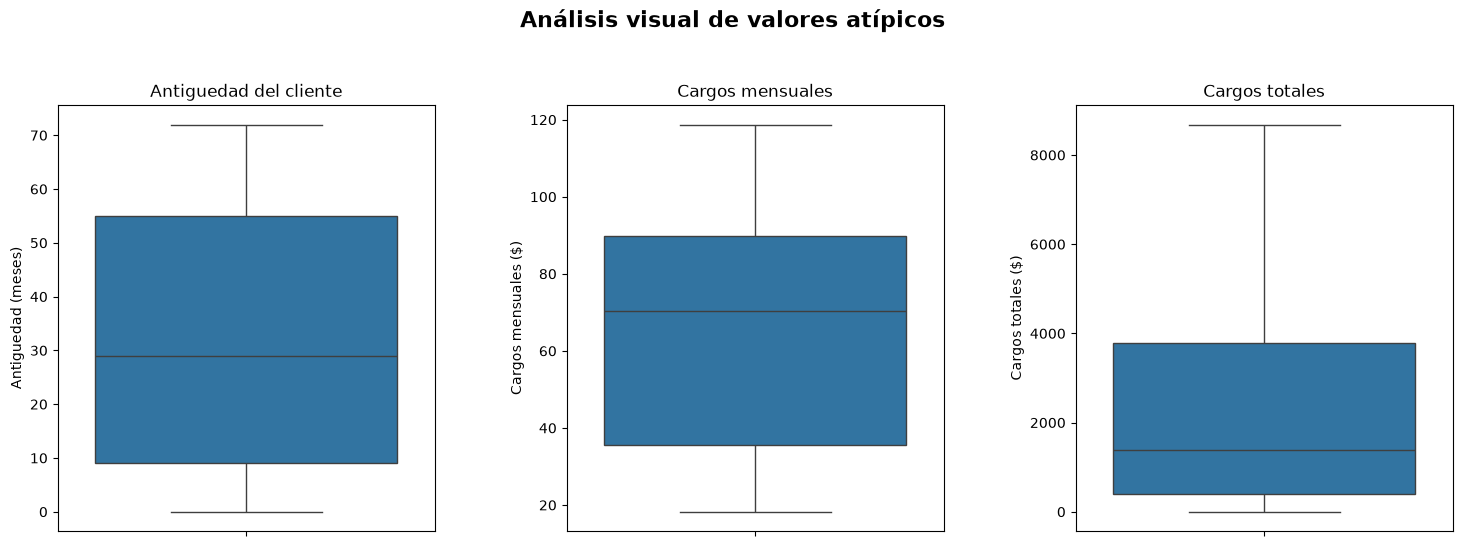

In [18]:
# crear una figura con múltiples espacios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Análisis visual de valores atípicos", fontsize=16, fontweight="bold")

# dibujar cada gráfico de caja con nombres descriptivos en español
sns.boxplot(y=df["tenure"], ax=axes[0])
axes[0].set_title("Antiguedad del cliente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Antiguedad (meses)")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Cargos mensuales")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cargos mensuales ($)")

sns.boxplot(y=df["TotalCharges"], ax=axes[2])
axes[2].set_title("Cargos totales")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cargos totales ($)")

plt.subplots_adjust(wspace=0.35, top=0.82)
plt.show()

* No se encontraron valores atípicos en las variables numéricas analizadas

## Análisis Descriptivo

#### Estadísticas básicas

In [19]:
# estadísticas descriptivas de las variables categóricas
df.describe(include="object").T.drop("customerID_Hash", axis=0)

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Hallazgos relevantes:

* La distribución por género es equilibrada: hay 3555 hombres y 3488 mujeres
* La clase positiva **Churn = Yes**, que representa a los clientes que sí abandonan el servicio, contiene 1869 registros (26,5%)
* La mayoría de los clientes no son adultos mayores: **SeniorCitizen** = 0 representa aproximadamente el 83,8%
* El contrato más frecuente es mensual, con 3875 clientes, lo que representa aproximadamente el 55%
* Cerca del 90,3% de los clientes tiene servicio telefónico

In [20]:
# estadísticas descriptivas de variables numéricas
df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


- La antiguedad mediana es de 29 meses, mientras que la media es de 32,37 meses
- Los cargos mensuales tienen una mediana de $70,35, con valores entre $18,25 y $118,75
- **TotalCharges** presenta una mediana de $1394,55 y una media de $2279,73

### Variable Objetivo

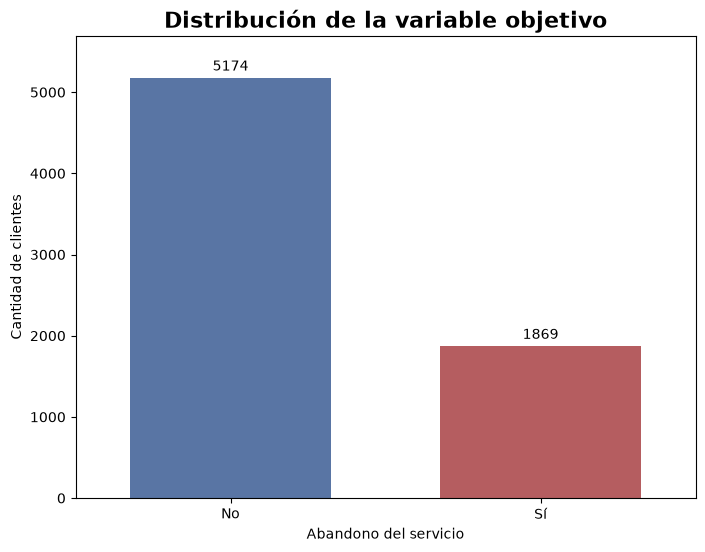

In [21]:
fig, ax = visualizaciones.graficar_distribucion_churn(df)
plt.show()

* La tasa general de churn es del 26.5%. Veamos entonces los distintos grupos de clientes. ¿Qué grupos presentan una mayor probabilidad de abandono?

### Características Numéricas

Para las variables numéricas, se calculan y grafican las funciones de estimación de densidad de kernel (KDE).

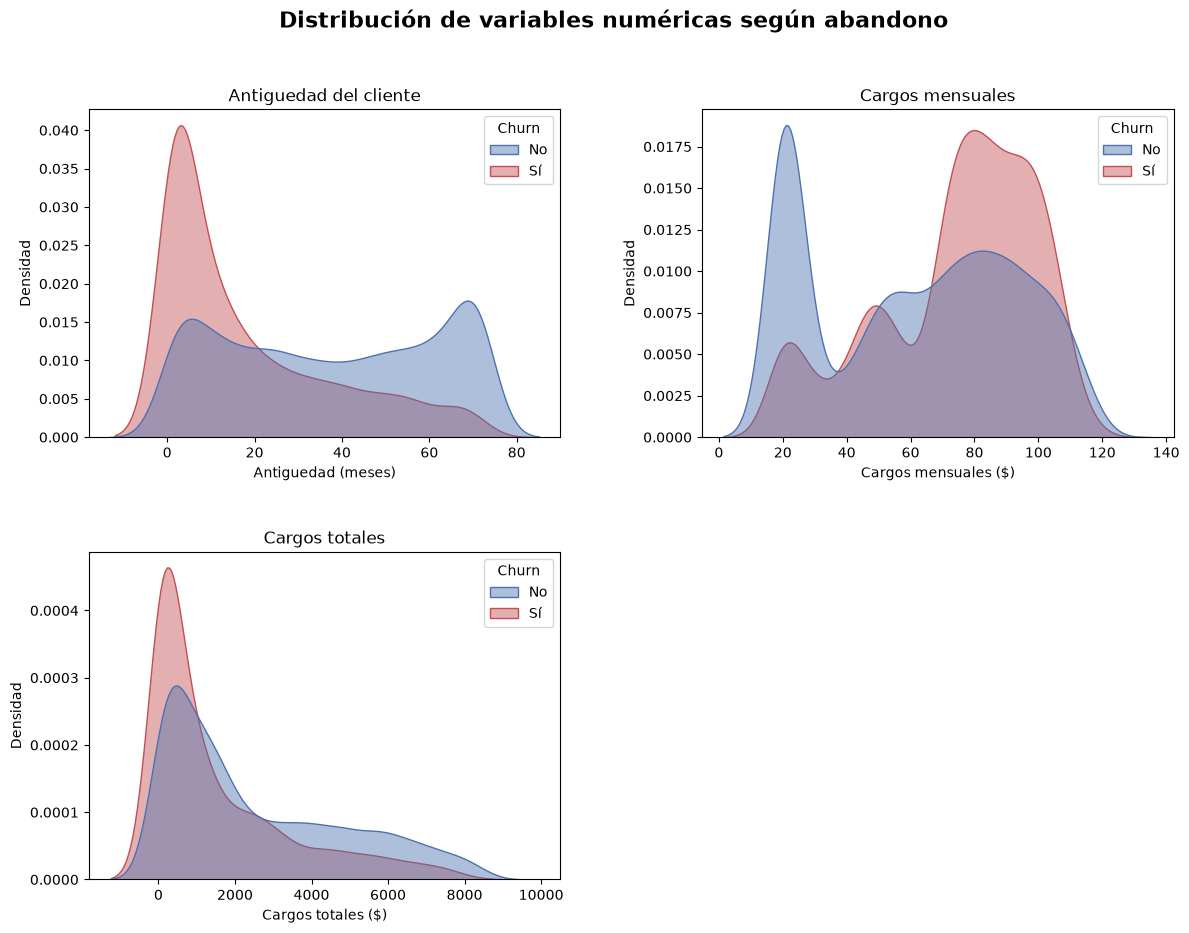

In [22]:
# generar curvas de densidad según la variable Churn
fig, axes = visualizaciones.graficar_curvas_densidad_churn(df)
plt.show()

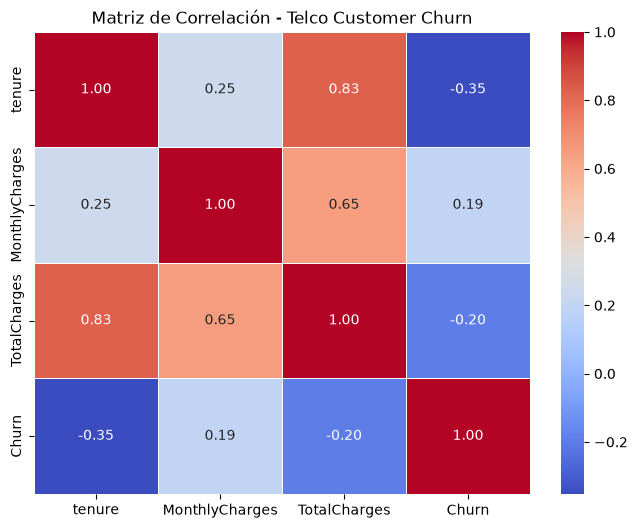

In [23]:
# mapa de calor matriz de correlaciones variables numéricas
df_copy = df.copy()
df_copy["Churn"] = df_copy["Churn"].map({"No": 0, "Yes": 1}).astype(object)
df_copy["Churn"] = pd.to_numeric(df_copy["Churn"], errors="coerce")
numeric_df = df_copy.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(columns=['customerID_Hash'], errors='ignore')
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Telco Customer Churn')
plt.show()

* Antiguedad y Cargos Totales (0,825): Fuerte correlación positiva. Como es lógico, los clientes que llevan más tiempo en la empresa acumulan un gasto total mayor.

* Antiguedad y Cargos Mensuales (0,248): Correlación positiva débil. Existe una ligera tendencia donde los clientes más antiguos asumen tarifas mensuales un poco más altas, lo que sugiere que podrían estar contratando servicios de mayor precio.

In [24]:
# agrupar por 'Churn' y calcular el promedio
resumen = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)
tabla_churn_numeric = resumen.T
tabla_churn_numeric.columns = ['Churn = No', 'Churn = Sí']
tabla_churn_numeric

,Churn = No,Churn = Sí
tenure,37.57,17.98
MonthlyCharges,61.27,74.44
TotalCharges,2549.91,1531.80


Se pueden extraer las siguientes conclusiones:

**Antiguedad (Meses):**

* Los clientes activos tienen una antiguedad promedio de 37,57 meses.
* Quienes cancelaron el servicio muestran una permanencia menor, con un promedio de 17,98 meses.
* A mayor tiempo en la compañía, menor es la probabilidad de abandono.
* Los clientes nuevos con poca antiguedad tienen más probabilidades de cambiar de compañía.

**Cargos Mensuales:**

* El pago mensual promedio de los clientes activos es de $61,27.
* Quienes se dieron de baja pagaban una tarifa un poco mayor, cercana a los $74,44.
* Los clientes que pagan cargos mensuales más altos también tienen más probabilidades de cancelar el servicio.

**Cargos Totales:**

* Los clientes que mantienen su suscripción acumulan un promedio de $2554,77 en cargos totales.
* Quienes cancelaron el servicio acumularon un gasto inferior, de alrededor de $1531,80.
* Los usuarios con un mayor gasto total acumulado en el tiempo son más propensos a quedarse en la empresa.

### Variables Categóricas

Para las variables categóricas, los gráficos de barras muestran las diferencias entre los grupos objetivo.

#### Información de Clientes

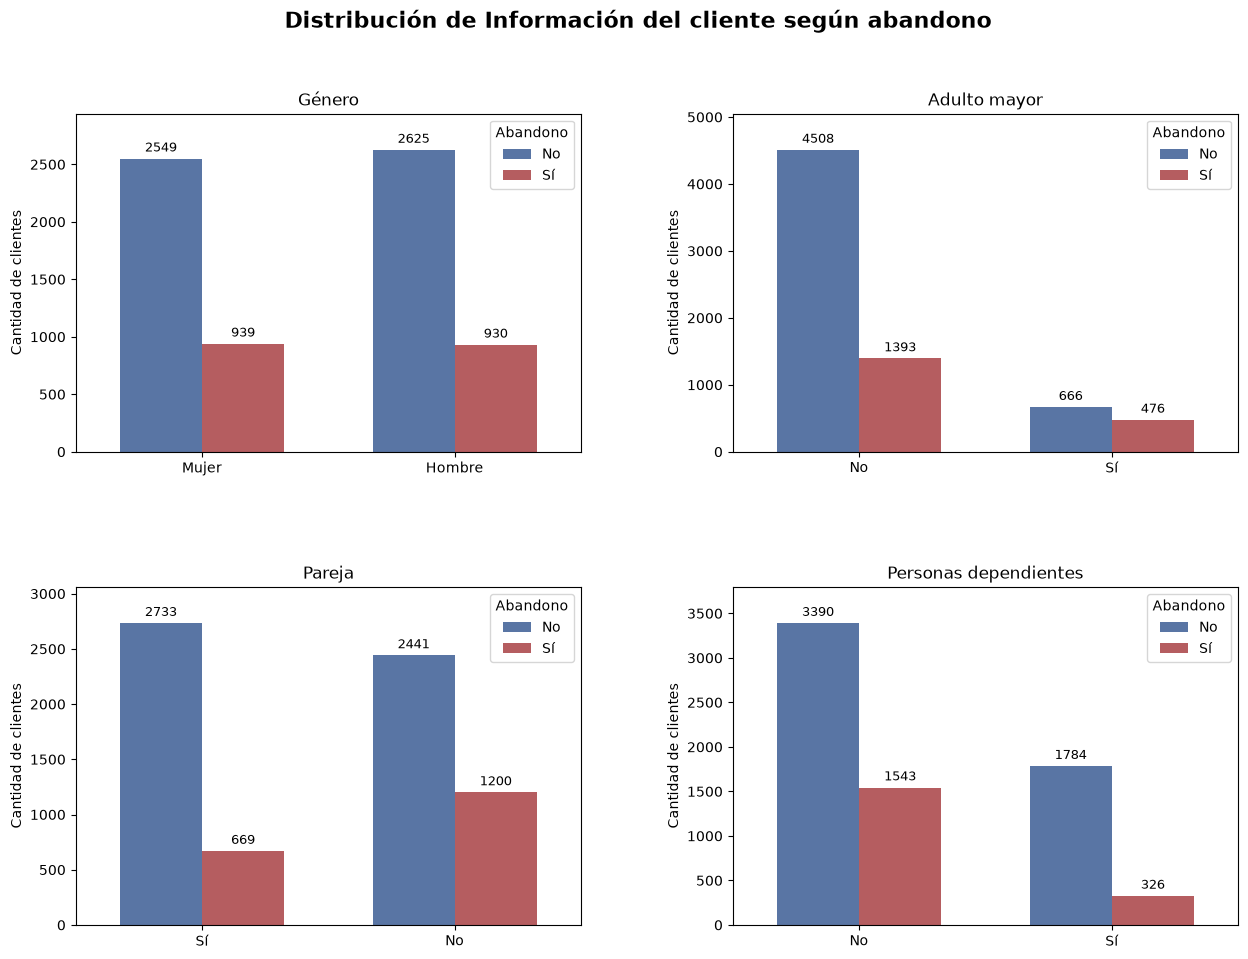

In [25]:
figura_cliente = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Información del cliente",
)
display(figura_cliente)
plt.close(figura_cliente)

* La cantidad de cancelaciones es muy similar entre clientes hombres y mujeres, sin presentar una diferencia importante.
* Clientes sin pareja y clientes sin familiares (dependientes), así como los adultos mayores en proporción tiene mayor probabilidad de abono.
* La mayor parte de los clientes que son adultos mayores termina cancelando su servicio.

#### Servicios Contratados

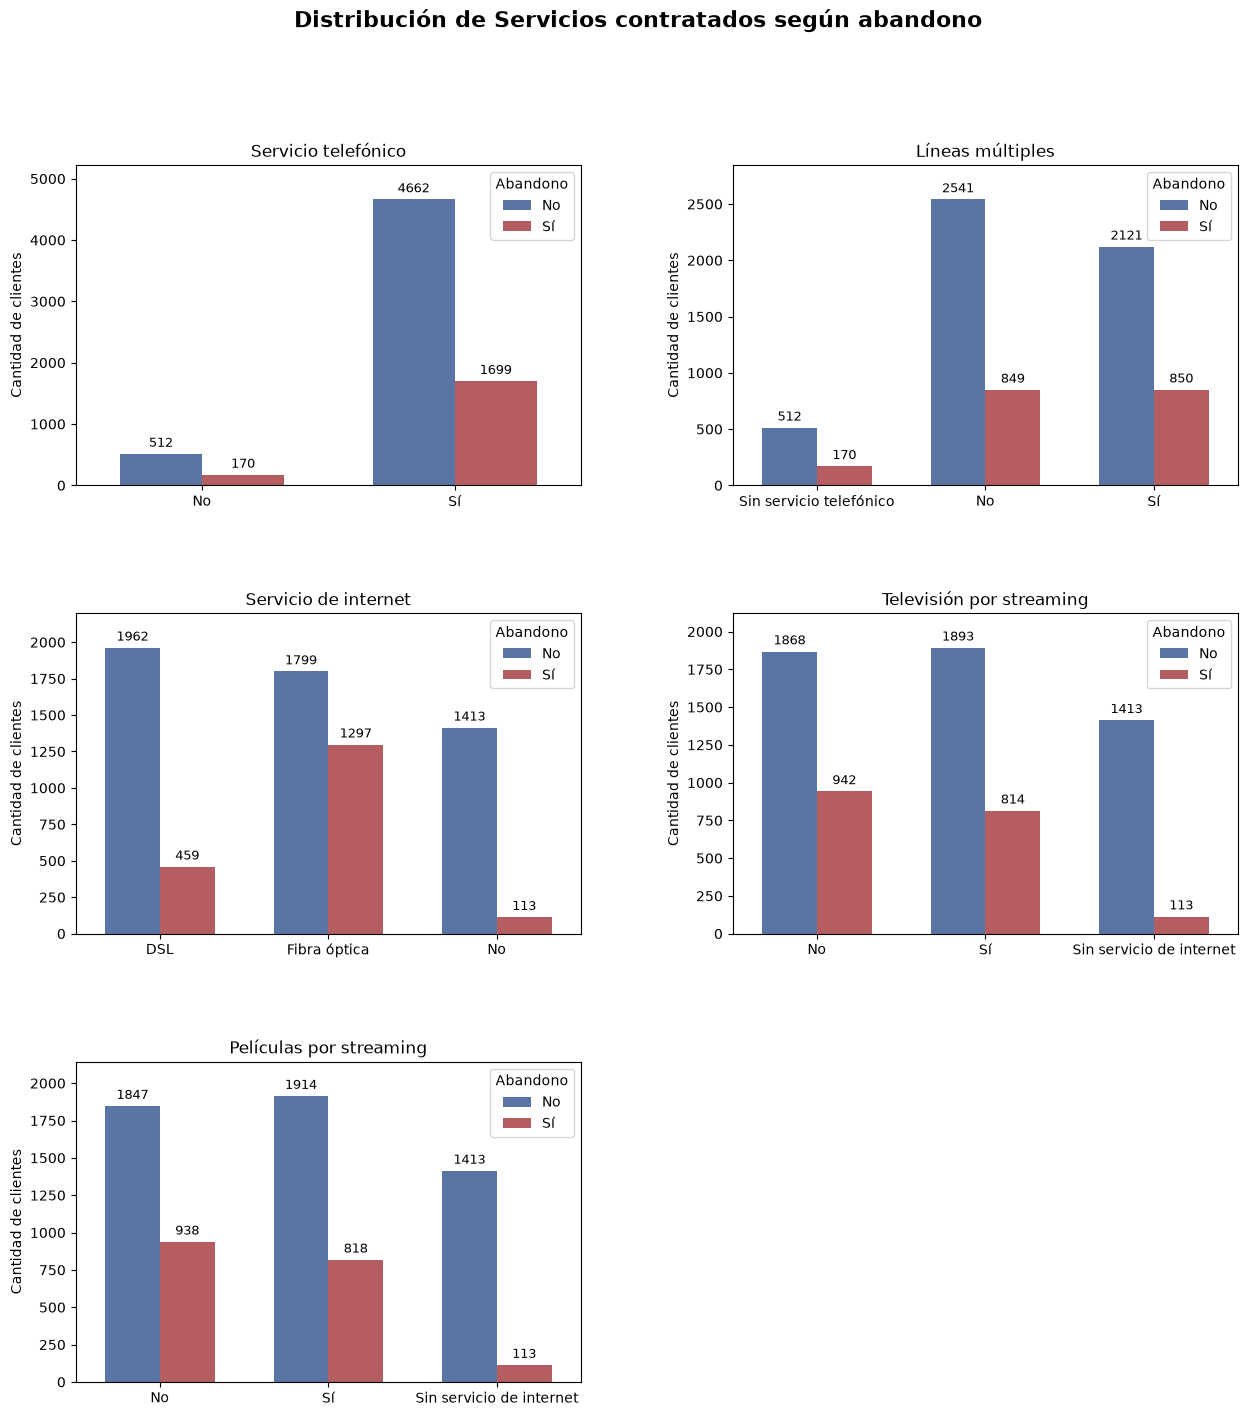

In [26]:
figura_servicios = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Servicios contratados"
)
display(figura_servicios)
plt.close(figura_servicios)

* Un alto número de clientes con internet de fibra óptica cancelaron su servicio.
* Los usuarios con conexión DSL abandonan la compañía con menor frecuencia.
* Los clientes que no cuentan con servicio de internet presentan una tasa de abandono muy baja.
* Una gran parte de los clientes elige el servicio de fibra óptica, pero presentan una alta tasa de abandono, lo que sugiere una posible insatisfacción con este tipo de conexión.

#### Seguridad y soporte

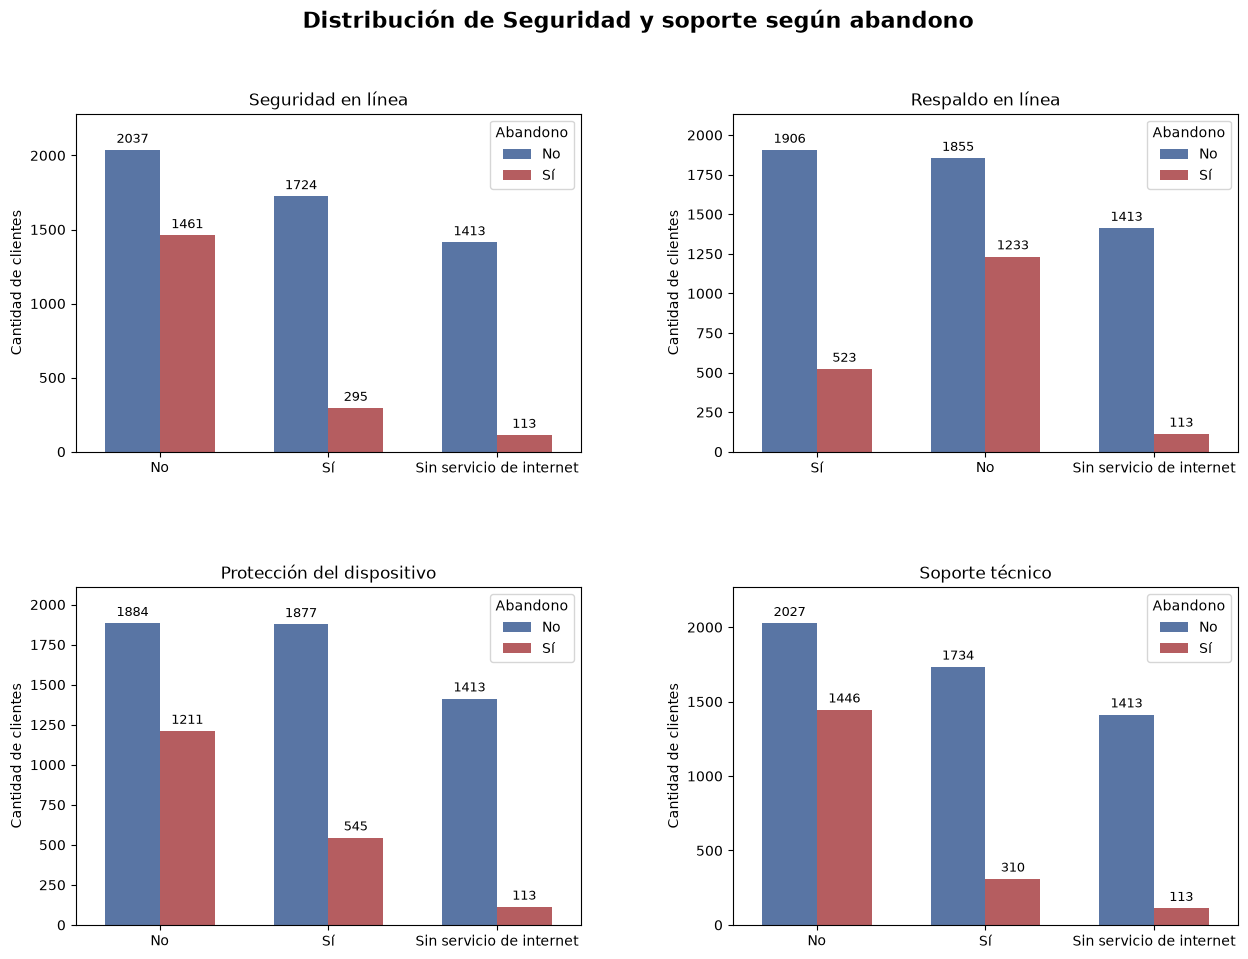

In [27]:
figura_seguridad = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Seguridad y soporte"
)
display(figura_seguridad)
plt.close(figura_seguridad)

* Seguridad en línea y Soporte técnico son los servicios que más protegen la retención, bajando el abandono de un 42% (clientes sin el servicio) a solo un 15% (clientes con el servicio).
* Respaldo y Protección del dispositivo también muestran un impacto positivo logrando reducir el nivel de fuga de un 40% a un 22%.
* Los clientes que contrataron servicios de seguridad o soporte técnico adicional tienen menos probabilidades de cancelar su servicio. Resulta clave ofrecer promociones que incluyan seguridad o soporte técnico.

#### Información de Pago

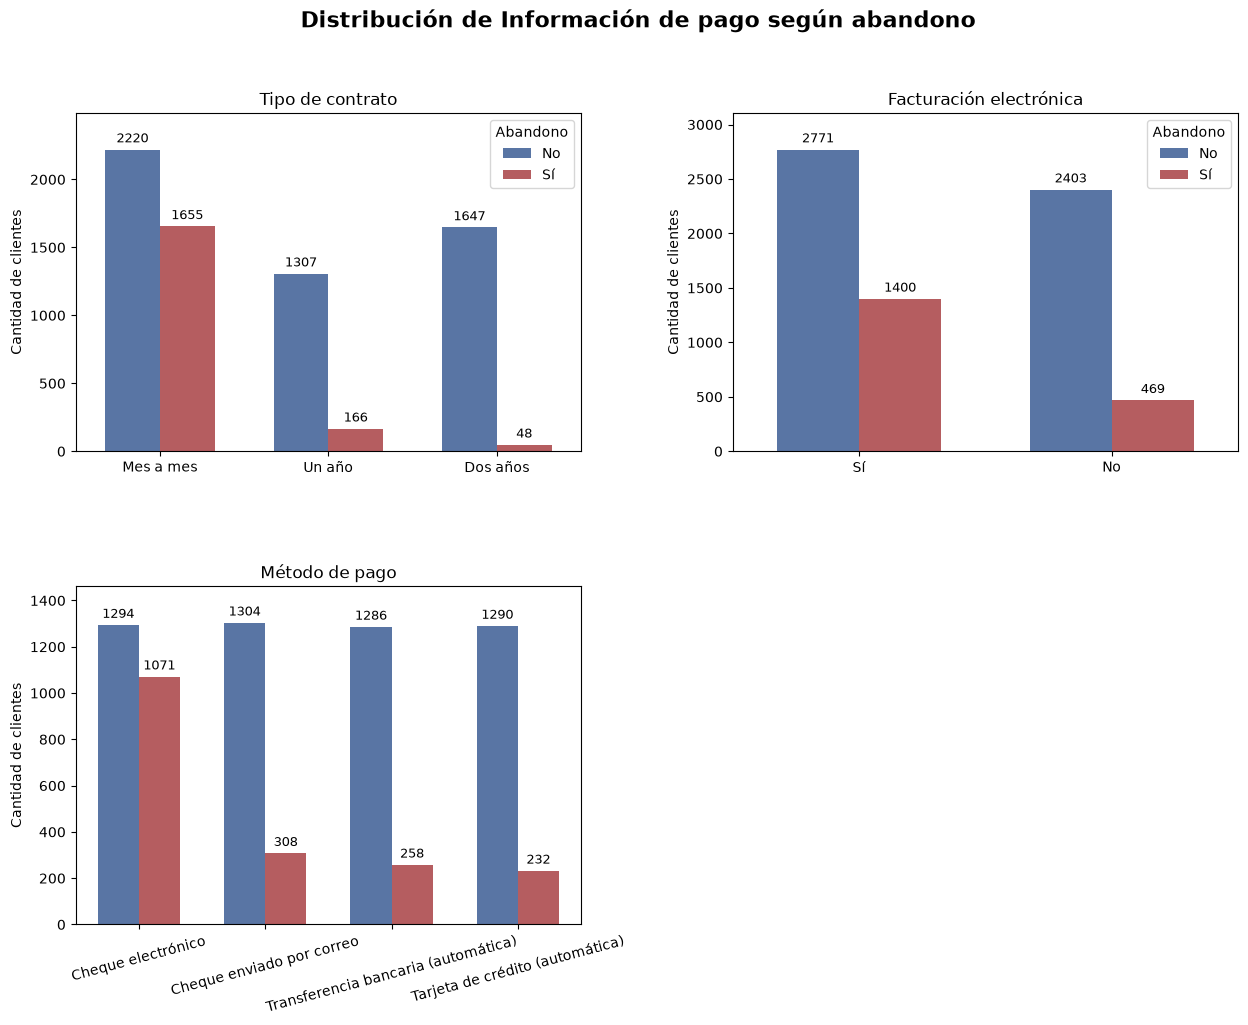

In [28]:
figura_pago = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Información de pago"
)
display(figura_pago)
plt.close(figura_pago)

* El abandono es crítico en la modalidad "Mes a mes" (42.7%), pero disminuye drásticamente en compromisos de "Un año" (11.2%) y "Dos años" (2.8%).
* Los clientes con facturación electrónica presentan el doble de tasa de abandono (33.5%) que aquellos con facturación tradicional (16.3%).
* El "Cheque electrónico" es el método de mayor riesgo con un 45.2% de fuga, mientras que las otras alternativas promedian un abandono mucho menor (15-19%).


* Es prioritario incentivar contratos largos. Ofrecer beneficios para que los clientes mensuales pasen a planes anuales o de dos años, donde la tasa de abandono es casi nula.
* Se sugiere revisar el cheque electrónico. Es importante investigar por qué este método genera tantas cancelaciones y sugerir activamente a los clientes que cambien al pago automático.
* Se debe fidelizar al cliente digital. Ya que la facturación electrónica facilita la cancelación, necesitamos buscar nuevas formas de recordarles el valor del servicio para que decidan quedarse.



## Correlaciones de variables categóricas con Churn

In [29]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in ['customerID_Hash', 'Churn']:
    if col in cat_cols:
        cat_cols.remove(col)

In [30]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r- ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    min_denom = min((kcorr-1), (rcorr-1))
    if min_denom == 0:
        return 1.0 
    return np.sqrt(phi2corr / min_denom)

In [31]:
churn_corr = {}
for col in cat_cols:
    churn_corr[col] = cramers_v(df[col], df['Churn'])

In [32]:
corr_df = pd.DataFrame.from_dict(churn_corr, orient='index', columns=['Correlación con Churn'])
corr_df = corr_df.sort_values(by='Correlación con Churn', ascending=False)

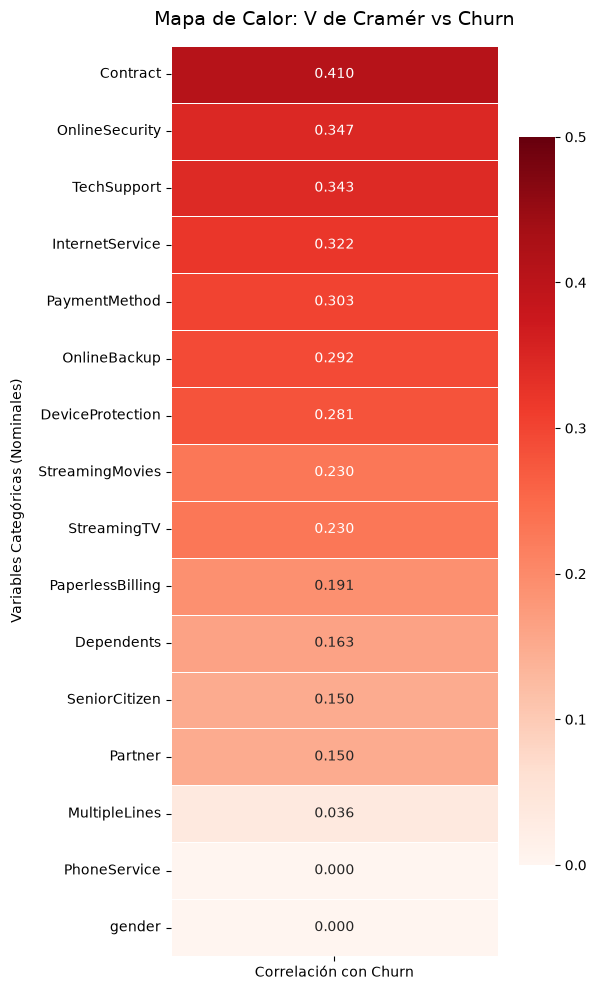

In [33]:
plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_df, 
    annot=True, 
    cmap='Reds',      # Escala de rojos para advertir riesgo de abandono
    fmt=".3f", 
    linewidths=.5, 
    vmin=0, 
    vmax=0.5,         # Ajustar el máximo a 0.5 resalta el contraste del bloque superior
    cbar_kws={"shrink": .8}
)
plt.title("Mapa de Calor: V de Cramér vs Churn", fontsize=14, pad=15)
plt.ylabel("Variables Categóricas (Nominales)", labelpad=10)
plt.tight_layout()
plt.show()

#### Selección de Mejores Variables Predictoras
Construcción de listados para preprocesamiento

In [34]:
numericas = [
    'tenure', 
    'MonthlyCharges', 
    'TotalCharges', 
    'Aumento_Tarifa', # nueva variable: Diferencia de tarifa
    'Total_Servicios_Extra' # nueva: Nivel de Lock-in
]

categoricas_binarias = [
    'PaperlessBilling', 
    'Pago_Automatico', 
    'Vive_Solo',
    'Perfil_Alto_Riesgo'
]

categoricas_nominales = [
    'InternetService' # categorías: 'DSL', 'Fiber optic', 'No'
]

categoricas_ordinales = [
    'Contract' # categorías: 'Month-to-month' < 'One year' < 'Two year'
]

jerarquia_contrato = [['Month-to-month', 'One year', 'Two year']]

In [35]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(object)
df["Churn"] = pd.to_numeric(df["Churn"], errors="coerce")

* Manipulamos el formato de los valores de la variable objetivo para que el modelo interprete de mejor manera. YES/NO -> 1/0

# 2. Construcción de modelos de aprendizaje supervisado

Se implementan pipelines de transformación numérica y categórica, se crea un transformador personalizado (`TelcoFeatureEngineer`) para generar variables clave, y se divide el dataset estratificando la variable objetivo (80% entrenamiento / 20% prueba).

## Modelo de Regresión Logística

*   **Transformaciones específicas:** Usamos el pipeline numérico base (tratamiento de valores atípicos con `Winsorizer` y escalamiento con `MinMaxScaler`), paso vital porque este algoritmo es muy sensible a los valores extremos y a las diferencias de escala.
*   **Configuración del modelo:** Aplicamos `LogisticRegression` con `max_iter=1000`, clases balanceadas (`class_weight='balanced'`)

#### Pipelines de Transformación


In [36]:
pipeline_numerico = Pipeline([
    ("winsorizer", Winsorizer(capping_method='quantiles', tail='both', fold=0.05)),
    ("imputer", SimpleImputer(strategy="mean")),
    ('scaler', MinMaxScaler())
])

pipeline_categorico_nominal = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False)
    )
])

pipeline_categorico_binario = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

pipeline_categorico_ordinal = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=jerarquia_contrato, handle_unknown='use_encoded_value', unknown_value=-1))
])
    
pipeline_preprocessor = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numericas),
        ("cat_nom", pipeline_categorico_nominal, categoricas_nominales),
        ("cat_bin", pipeline_categorico_binario, categoricas_binarias),  
        ("cat_ord", pipeline_categorico_ordinal, categoricas_ordinales) 
    ],
    remainder = "drop"
)

#### Pipeline de Modelo LR

In [37]:
pipeline_final_lr = Pipeline(steps=[
    ('ingenieria_caracteristicas', TelcoFeatureEngineer(drop_original=True, drop_addons=True)),
    ('preprocesador', pipeline_preprocessor),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        max_iter=1000, 
        random_state=42
    ))
])

#### División de los Datos

In [38]:
X = df.drop(columns=['Churn', "customerID_Hash"])

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    stratify=y,
    random_state=42
)

#### Entrenamiento y Evaluación LR

In [39]:
pipeline_final_lr.fit(X_train, y_train)

y_pred = pipeline_final_lr.predict(X_test)

reporte = classification_report(y_test, y_pred, output_dict=True)
df_reporte = pd.DataFrame(reporte).transpose().round(3)
display(df_reporte)

,precision,recall,f1-score,support
0,0.902,0.698,0.787,1035.000
1,0.486,0.791,0.602,374.000
accuracy,0.722,0.722,0.722,0.722
macro avg,0.694,0.745,0.695,1409.000
weighted avg,0.792,0.722,0.738,1409.000


El modelo logró una Exactitud del 72.2%. Como muestran los gráficos generados, identificó correctamente 296 fugas (Verdaderos Positivos), reduciendo los Falsos Negativos a 78 clientes no detectados. A cambio, generó 313 Falsos Positivos. La curva ROC respalda este rendimiento con un AUC de 0.831, demostrando una buena capacidad general para separar las clases.

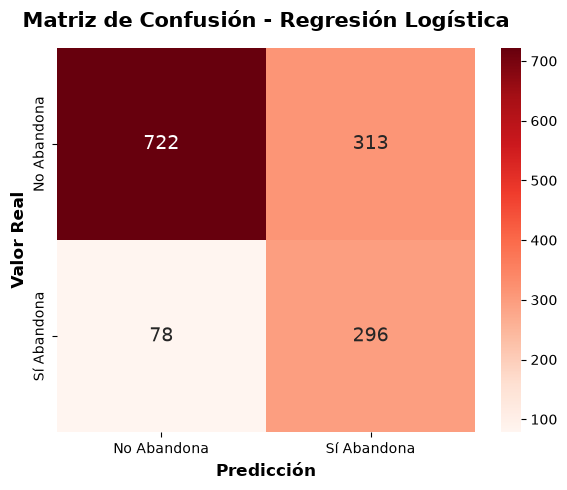

In [40]:
# Graficar Matriz de confusión para modelo de Regresión Logística
plot_matriz_confusion(y_test, y_pred, nombre_modelo="Regresión Logística")

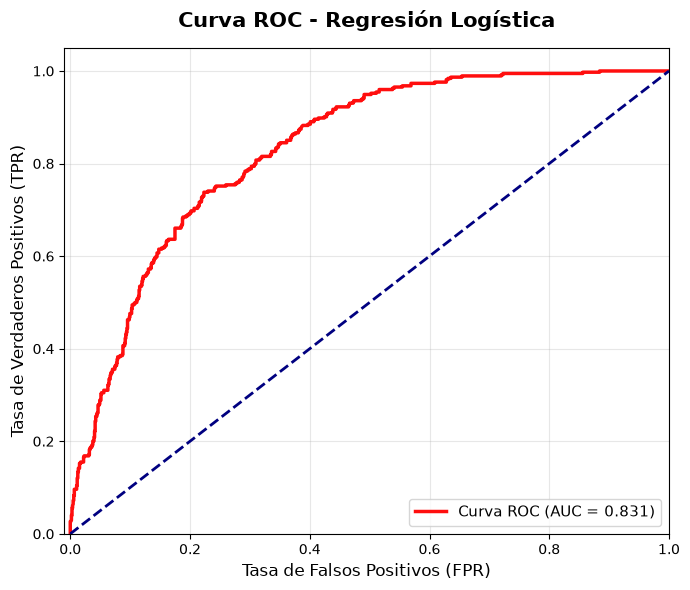

In [41]:
# Grafica Curva ROC para modelo de Regresión Logística
y_test_proba = pipeline_final_lr.predict_proba(X_test)[:, 1]
plot_curva_roc(y_test, y_test_proba, nombre_modelo="Regresión Logística")

## Modelo de Máquinas de Vectores de Soporte (SVM)

*   **Transformaciones específicas:** Se incluye el escalamiento numérico (`MinMaxScaler`), obligatorio para SVM porque se basa en calcular distancias.
*   **Configuración del modelo:** Usamos `SVC` con un kernel radial (`kernel='rbf'`), cálculo de probabilidades activado para generar la curva ROC y clases balanceadas.

#### Pipeline del Modelo SVM

In [42]:
pipeline_final_svm = Pipeline(steps=[
    ('ingenieria_caracteristicas', TelcoFeatureEngineer(drop_original=True, drop_addons=True)),
    ('preprocesador', pipeline_preprocessor),
    ('modelo', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

#### Entrenamiento y Evaluación SVM

In [43]:
# Entrenamiento y predicción
pipeline_final_svm.fit(X_train, y_train)

y_pred_svm = pipeline_final_svm.predict(X_test)

reporte = classification_report(y_test, y_pred_svm, output_dict=True)
df_reporte = pd.DataFrame(reporte).transpose().round(3)
display(df_reporte)

,precision,recall,f1-score,support
0,0.896,0.722,0.799,1035.000
1,0.499,0.767,0.605,374.000
accuracy,0.734,0.734,0.734,0.734
macro avg,0.697,0.745,0.702,1409.000
weighted avg,0.790,0.734,0.748,1409.000


Obtuvo la Exactitud más alta (73.4%). Sin embargo, la matriz de confusión revela que es peor para la retención: identificó 287 fugas, pero dejó escapar 87 Falsos Negativos (clientes que se van sin ser detectados), sumado a 288 Falsos Positivos. Su AUC de 0.813 confirma que predice bien, pero separa un poco peor las clases que la Regresión Logística.

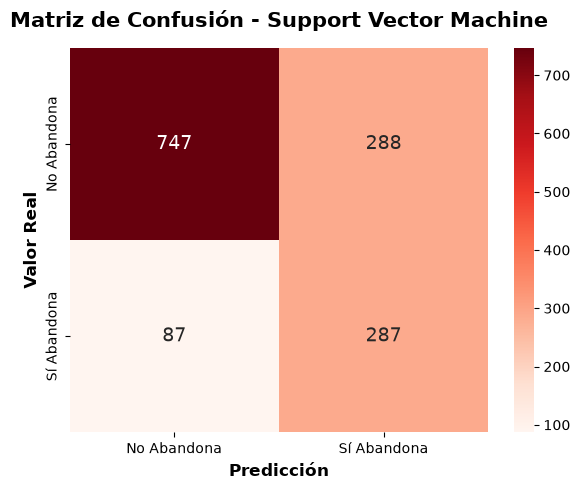

In [44]:
# Visualizaciones
plot_matriz_confusion(y_test, y_pred_svm, nombre_modelo="Support Vector Machine")

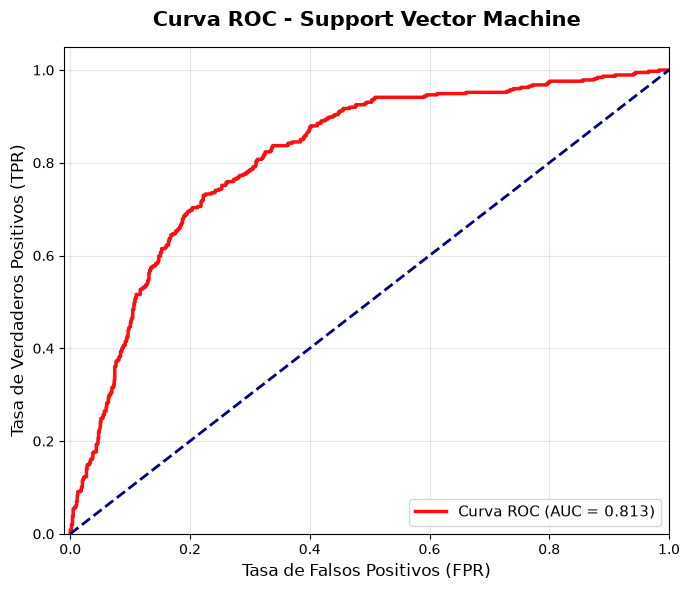

In [45]:
y_proba_svm = pipeline_final_svm.predict_proba(X_test)[:, 1]
plot_curva_roc(y_test, y_proba_svm, nombre_modelo="Support Vector Machine")

## Modelo de Árbol de Decisión (DecisionTreeClassifier)

*   **Transformaciones específicas:** Usamos un pipeline independiente que solo rellena nulos (`SimpleImputer`). No se aplicó escalamiento ni manejo de atípicos porque a los árboles (basados en reglas lógicas) no les afecta la escala.
*   **Configuración del modelo:** Se limitó la profundidad a 5 niveles (`max_depth=5`) para evitar el sobreajuste, conservando el peso balanceado.

In [46]:
# pipeline numérico sin escalamiento ni tratamiento de outliers
pipeline_numerico_arbol = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

pipeline_preprocessor_arbol = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico_arbol, numericas),
        ("cat_nom", pipeline_categorico_nominal, categoricas_nominales),
        ("cat_bin", pipeline_categorico_binario, categoricas_binarias),  
        ("cat_ord", pipeline_categorico_ordinal, categoricas_ordinales) 
    ],
    remainder="drop"
)

#### Pipeline del Modelo DTC

In [47]:
pipeline_final_dtc = Pipeline(steps=[
    ('ingenieria_caracteristicas', TelcoFeatureEngineer(drop_original=True, drop_addons=True)),
    ('preprocesador', pipeline_preprocessor_arbol),
    ('modelo', DecisionTreeClassifier(
        max_depth=5,              
        class_weight='balanced',  
        random_state=42
    ))
])

In [48]:
# Entrenamiento y predicción
pipeline_final_dtc.fit(X_train, y_train)

y_pred_dtc = pipeline_final_dtc.predict(X_test)

reporte = classification_report(y_test, y_pred_dtc, output_dict=True)
df_reporte = pd.DataFrame(reporte).transpose().round(3)
display(df_reporte)

,precision,recall,f1-score,support
0,0.913,0.672,0.775,1035.000
1,0.476,0.824,0.603,374.000
accuracy,0.713,0.713,0.713,0.713
macro avg,0.695,0.748,0.689,1409.000
weighted avg,0.797,0.713,0.729,1409.000


Logró la Exactitud general más baja (71.3%), pero destacó consiguiendo el Recall más alto (0.824). Como se observa arriba, detectó 308 fugas y bajó los Falsos Negativos a solo 66 casos. El costo de ser tan sensible fueron 339 Falsos Positivos. Su AUC de 0.827 refleja que compite de cerca con los otros modelos paramétricos.

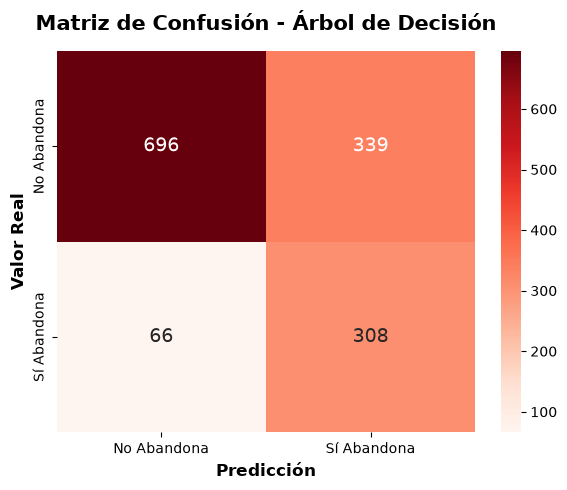

In [49]:
plot_matriz_confusion(y_test, y_pred_dtc, nombre_modelo="Árbol de Decisión")

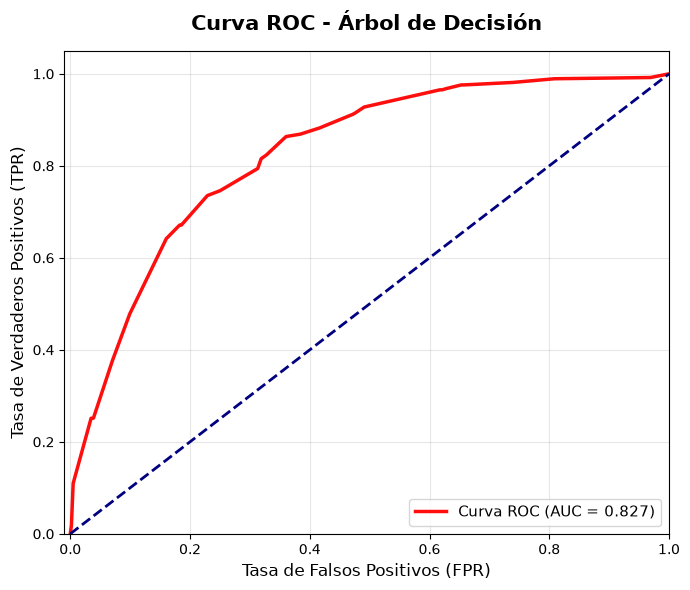

In [50]:
y_proba_dtc = pipeline_final_dtc.predict_proba(X_test)[:, 1]
plot_curva_roc(y_test, y_proba_dtc, nombre_modelo="Árbol de Decisión")

# 3. Cierre del Notebook

Guiarnos solo por la Exactitud (Accuracy) no sirve por el desbalance de clases. Para el negocio, duele mucho más un Falso Negativo (perder un cliente sin darnos cuenta) que un Falso Positivo (ofrecer un beneficio innecesario). 

Tabla resumen para la clase objetivo (Fuga):

| Modelo | Exactitud | Precisión | Recall | F1-Score | Falsos Negativos | Falsos Positivos | AUC |
|---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| Regresión Logística | 72.2% | 0.486 | 0.791 | 0.602 | 78 | 313 | 0.831 |
| SVM (RBF) | 73.4% | 0.499 | 0.767 | 0.605 | 87 | 288 | 0.813 |
| Árbol de Decisión | 71.3% | 0.476 | **0.824** | 0.603 | **66** | 339 | 0.827 |

# 4. Recomendación de modelo

Para este proyecto, la métrica clave a optimizar es el **Recall (Exhaustividad)**, ya que el objetivo es lanzar campañas de retención a tiempo.

Seleccionamos el **Árbol de Decisión (`DecisionTreeClassifier`)** como el modelo ganador. 

Alcanzó el Recall más alto (0.824), reduciendo las fugas no detectadas a solo 66 casos. Aunque genera más Falsos Positivos (339), el costo de enviarle un descuento a un cliente estable es mínimo en comparación con perder todos los ingresos futuros de los 21 clientes extra que el árbol logra salvar frente al modelo SVM. Es el algoritmo que mejor se alinea con la estrategia comercial de proteger la cartera de clientes.